In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import PyMieScatt as ps
import pymiediff as pmd

# Reproducibility — same "random" numbers every run
np.random.seed(42)
torch.manual_seed(42)

theta shape: (181,)
SU shape: (181,)
First few SU values: [274.50568018 273.77890685 271.60879971 268.02578541 263.07987412]


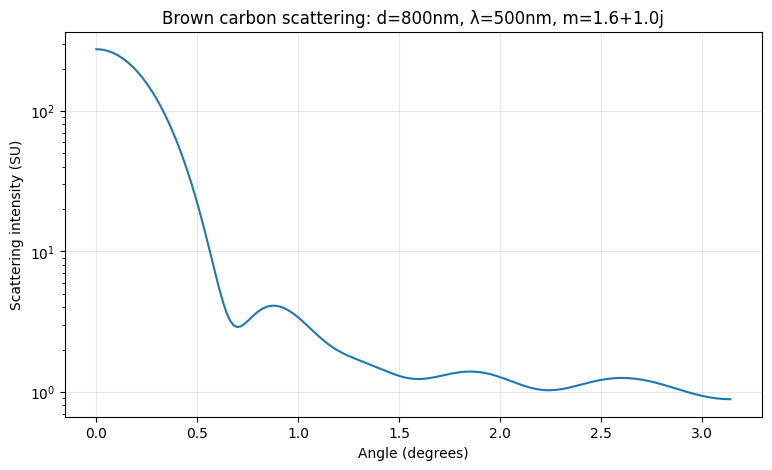

In [2]:
# Brown carbon at the center of our range
n = 1.6
k = 1.0
wavelength = 500   # nm
diameter = 800     # nm

m = complex(n, k)
theta, SL, SR, SU = ps.ScatteringFunction(
    m, wavelength, diameter,
    minAngle=0, maxAngle=180, angularResolution=1
)

print("theta shape:", theta.shape)
print("SU shape:", SU.shape)
print("First few SU values:", SU[:5])

plt.figure(figsize=(9, 5))
plt.plot(theta, SU)
plt.xlabel("Angle (degrees)")
plt.ylabel("Scattering intensity (SU)")
plt.title(f"Brown carbon scattering: d={diameter}nm, λ={wavelength}nm, m=1.6+1.0j")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
N_PARTICLES = 500
N_ANGLES = 181
N_SAMPLES = N_PARTICLES * N_ANGLES # total training samples

# Pre-allocate arrays
inputs = np.zeros((N_SAMPLES, 5))     # 5 features: wavelength, diameter, n, k, angle. Has the same parameters repeated in groups of 181
outputs = np.zeros((N_SAMPLES,))  # single brightness value for every sample input. Has unique values for every entry

print(f"Generating {N_PARTICLES} particles, {N_SAMPLES} (particle, angle) training rows through physics")
idx = 0

for i in range(N_PARTICLES):
    # Sample random wavelength and diameter
    wavelength = np.random.uniform(450, 550) # these things are probably randomly distributed in order to lower convergence time
    diameter = np.random.uniform(700, 900)
    n = np.random.uniform(1.5, 1.86) # following the paper from Liu et al
    k = np.random.uniform(0.68, 1.00) # following the paper from Liu et al
    m = complex(n, k)
    
    # Run Mie calculation, we'll treat this as the accurate data
    theta, SL, SR, SU = ps.ScatteringFunction(
        m, wavelength, diameter,
        minAngle=0, maxAngle=180, angularResolution=1
    )
    # unfold the pyMieScatt output into ouput points which each have a specific angle value
    for a in range(N_ANGLES):
        inputs[idx] = [n, k, wavelength, diameter, theta[a]]
        outputs[idx] = SU[a]
        idx += 1
    
    
    if i % 100 == 0:
        print(f"  {i}/{N_PARTICLES} particles done")

print(inputs)

print("\nDone!")
print("Inputs shape:", inputs.shape)
print("Outputs shape:", outputs.shape)

Generating 500 particles, 90500 (particle, angle) training rows through physics
  0/500 particles done
  100/500 particles done
  200/500 particles done
  300/500 particles done
  400/500 particles done
[[1.76351782e+00 8.71570715e-01 4.87454012e+02 8.90142861e+02
  0.00000000e+00]
 [1.76351782e+00 8.71570715e-01 4.87454012e+02 8.90142861e+02
  1.74532925e-02]
 [1.76351782e+00 8.71570715e-01 4.87454012e+02 8.90142861e+02
  3.49065850e-02]
 ...
 [1.52053970e+00 7.70299864e-01 5.45661462e+02 7.13791603e+02
  3.10668607e+00]
 [1.52053970e+00 7.70299864e-01 5.45661462e+02 7.13791603e+02
  3.12413936e+00]
 [1.52053970e+00 7.70299864e-01 5.45661462e+02 7.13791603e+02
  3.14159265e+00]]

Done!
Inputs shape: (90500, 5)
Outputs shape: (90500,)


generating sample data

Saved to disk


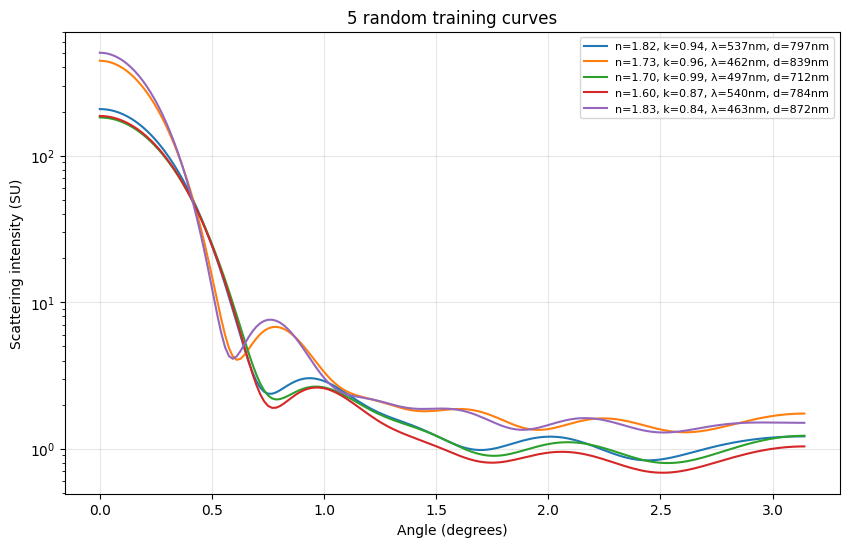

In [4]:
np.save('inputs_5d_10k.npy', inputs) # want to save training data
np.save('outputs_5d_10k.npy', outputs)
print(f"Saved to disk")

plt.figure(figsize=(10, 6))

# Pick 5 random PARTICLES (not rows)
particle_indices = np.random.choice(N_PARTICLES, 5, replace=False)

for p in particle_indices:
    # Get the 181 rows for this particle
    start = p * N_ANGLES
    end = start + N_ANGLES
    
    # Extract the curve and inputs
    curve = outputs[start:end]
    angles = inputs[start:end, 4]   # column 4 is the angle
    

    # Get the particle's other inputs (same for all 181 rows)
    n  = inputs[start, 0]
    k  = inputs[start, 1]
    wl = inputs[start, 2]
    d  = inputs[start, 3]
    
    label = f"n={n:.2f}, k={k:.2f}, λ={wl:.0f}nm, d={d:.0f}nm"
    plt.plot(angles, curve, label=label)

plt.xlabel("Angle (degrees)")
plt.ylabel("Scattering intensity (SU)")
plt.title("5 random training curves")
plt.yscale('log')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.show()

graphed 5 random training data points, just to see the shape of the results

In [5]:
# log-transform the outputs
log_outputs = np.log10(outputs+1e-10).reshape(-1,1)   # base-10 log, must reshape into 2d array, since pytorch wants 2d array for math

# normalize the inputs to roughly [0, 1]
# wavelength: 450-550 → (wavelength - 450) / 100
# diameter:   700-900 → (diameter - 700) / 200
inputs_norm = np.zeros_like(inputs)
inputs_norm[:, 0] = (inputs[:, 0] - 1.5) / (1.86 - 1.5)        # n
inputs_norm[:, 1] = (inputs[:, 1] - 0.68) / (1.00 - 0.68)      # k
inputs_norm[:, 2] = (inputs[:, 2] - 450) / 100                  # wavelength
inputs_norm[:, 3] = (inputs[:, 3] - 700) / 200                  # diameter
inputs_norm[:, 4] = inputs[:, 4] / np.pi  
print(inputs_norm)
# train/test split
n_train = int(0.8 * N_SAMPLES)
X_train = torch.FloatTensor(inputs_norm[:n_train])
y_train = torch.FloatTensor(log_outputs[:n_train])
X_test = torch.FloatTensor(inputs_norm[n_train:])
y_test = torch.FloatTensor(log_outputs[n_train:])

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print()
print("Sample input (normalized):", X_train[0])

[[0.73199394 0.59865848 0.37454012 0.95071431 0.        ]
 [0.73199394 0.59865848 0.37454012 0.95071431 0.00555556]
 [0.73199394 0.59865848 0.37454012 0.95071431 0.01111111]
 ...
 [0.05705472 0.28218707 0.95661462 0.06895802 0.98888889]
 [0.05705472 0.28218707 0.95661462 0.06895802 0.99444444]
 [0.05705472 0.28218707 0.95661462 0.06895802 1.        ]]
X_train shape: torch.Size([72400, 5])
y_train shape: torch.Size([72400, 1])
X_test shape: torch.Size([18100, 5])
y_test shape: torch.Size([18100, 1])

Sample input (normalized): tensor([0.7320, 0.5987, 0.3745, 0.9507, 0.0000])


Split the data into training and testing data, formatting the data so it's ready for training. Converting numpy arrays into Tensors.

In [6]:
model = nn.Sequential(
    nn.Linear(5, 128),       # input layer: 4 features to 128 neurons
    nn.GELU(),
    nn.Linear(128, 256),     # hidden layer: 128 to 256
    nn.GELU(),
    nn.Linear(256, 128),    # output layer: 256 to 256 (one per angle)
    nn.GELU(),
    nn.Linear(128,1)
    
)

print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params}")

Sequential(
  (0): Linear(in_features=5, out_features=128, bias=True)
  (1): GELU(approximate='none')
  (2): Linear(in_features=128, out_features=256, bias=True)
  (3): GELU(approximate='none')
  (4): Linear(in_features=256, out_features=128, bias=True)
  (5): GELU(approximate='none')
  (6): Linear(in_features=128, out_features=1, bias=True)
)

Total parameters: 66817


building NN layers, applying ReLu between each. Printing the model and counting the number of parameters.

In [7]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
loss_fn = nn.MSELoss()

print("Optimizer:", optimizer)
print("Loss function:", loss_fn)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
Loss function: MSELoss()


In [8]:
N_EPOCHS = 200
BATCH_SIZE = 128

train_losses = []
test_losses = []

n_train = X_train.shape[0]   # 8000 training data
n_batches = n_train // BATCH_SIZE  # 8000/128

print(f"Training: {N_EPOCHS} epochs, {n_batches} batches per epoch\n")

import time

training_start = time.time()

for epoch in range(N_EPOCHS):
    # Shuffle training data each epoch
    perm = torch.randperm(n_train)# generates a random permutation of the numbers up to 800
    X_shuffled = X_train[perm] # shuffle the training data according to the permutation
    y_shuffled = y_train[perm] # shuffle the 'answers' for the training data
    
    # Train one epoch (one pass through the data, in mini-batches)
    epoch_loss = 0.0
    for i in range(n_batches):
        start = i * BATCH_SIZE # index work to see where batch starts
        end = start + BATCH_SIZE # index work to see where each batch ends while looping through the batches
        X_batch = X_shuffled[start:end] # diameters and wavelengths used in this batch
        y_batch = y_shuffled[start:end] # light scattered at each angle in this batch
        
        # Standard 5-step training pattern
        pred = model(X_batch) # predict
        loss = loss_fn(pred, y_batch) # get the loss
        
        optimizer.zero_grad() # clears gradients from previous batches
        loss.backward() # back propagation to compute gradients for all weights
        optimizer.step() #updates all weights using the gradients
        
        epoch_loss += loss.item() # records the loss over the batches for graphing
    
    avg_train_loss = epoch_loss / n_batches # average across all 25 batches
    train_losses.append(avg_train_loss) # save avg loss for plotting
    
    # Evaluate on test set (no gradients needed)
    with torch.no_grad():
        test_pred = model(X_test) #predict on 200 test examples
        test_loss = loss_fn(test_pred, y_test).item() #compute MSE on test set
        test_losses.append(test_loss) # save it
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}  Train Loss: {avg_train_loss:.10f}  Test Loss: {test_loss:.10f}")

elapsed = time.time() - training_start
print(f"Total time: {elapsed:.2f}s")
print(f"Final loss: {train_losses[-1]:.6e}")
print("\nTraining complete!")


Training: 200 epochs, 565 batches per epoch

Epoch   0  Train Loss: 0.2376041730  Test Loss: 0.0414044037
Epoch  20  Train Loss: 0.0013445243  Test Loss: 0.0012002671
Epoch  40  Train Loss: 0.0009163865  Test Loss: 0.0009065950
Epoch  60  Train Loss: 0.0002783047  Test Loss: 0.0002852027
Epoch  80  Train Loss: 0.0001124151  Test Loss: 0.0001059097
Epoch 100  Train Loss: 0.0000458215  Test Loss: 0.0000491829
Epoch 120  Train Loss: 0.0000188540  Test Loss: 0.0000298207
Epoch 140  Train Loss: 0.0000173803  Test Loss: 0.0000108009
Epoch 160  Train Loss: 0.0000124733  Test Loss: 0.0000094533
Epoch 180  Train Loss: 0.0000135935  Test Loss: 0.0000120302
Total time: 124.14s
Final loss: 7.150063e-06

Training complete!


Training the model. Randomizing the sequence of the training set. Split the set into a training and testing set. Also making sure loss is decreasing over time, ensuring we are approaching a minimum in the cost. Training took 10.7 seconds


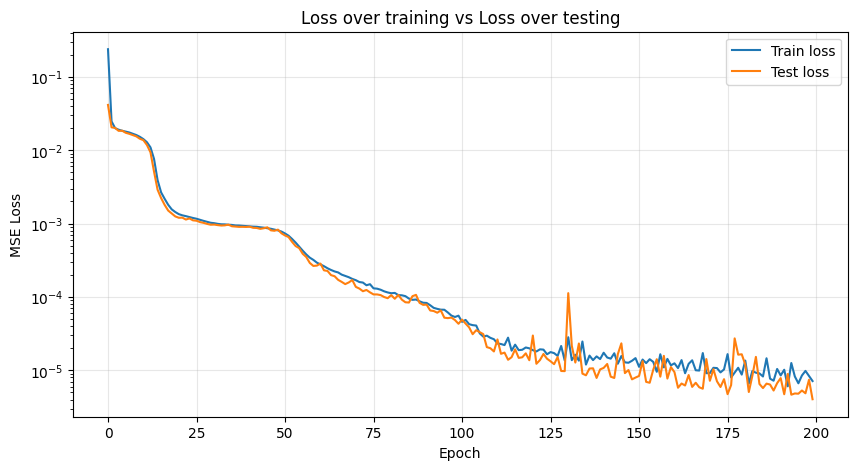

X_train shape: torch.Size([72400, 5])
y_train shape: torch.Size([72400, 1])
y_train min: -0.5165
y_train max: 2.7798
y_train mean: 0.4753
y_train variance: 0.5874

Final train loss: 0.0000
Final test loss: 0.0000


In [9]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train loss')
plt.plot(test_losses, label='Test loss')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss over training vs Loss over testing")
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_train min: {y_train.min().item():.4f}")
print(f"y_train max: {y_train.max().item():.4f}")
print(f"y_train mean: {y_train.mean().item():.4f}")
print(f"y_train variance: {y_train.var().item():.4f}")
print()
print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Final test loss: {test_losses[-1]:.4f}")

Printing X_test
tensor([[0.2267, 0.3550, 0.1919, 0.3234, 0.0000],
        [0.2267, 0.3550, 0.1919, 0.3234, 0.0056],
        [0.2267, 0.3550, 0.1919, 0.3234, 0.0111],
        ...,
        [0.0571, 0.2822, 0.9566, 0.0690, 0.9889],
        [0.0571, 0.2822, 0.9566, 0.0690, 0.9944],
        [0.0571, 0.2822, 0.9566, 0.0690, 1.0000]])


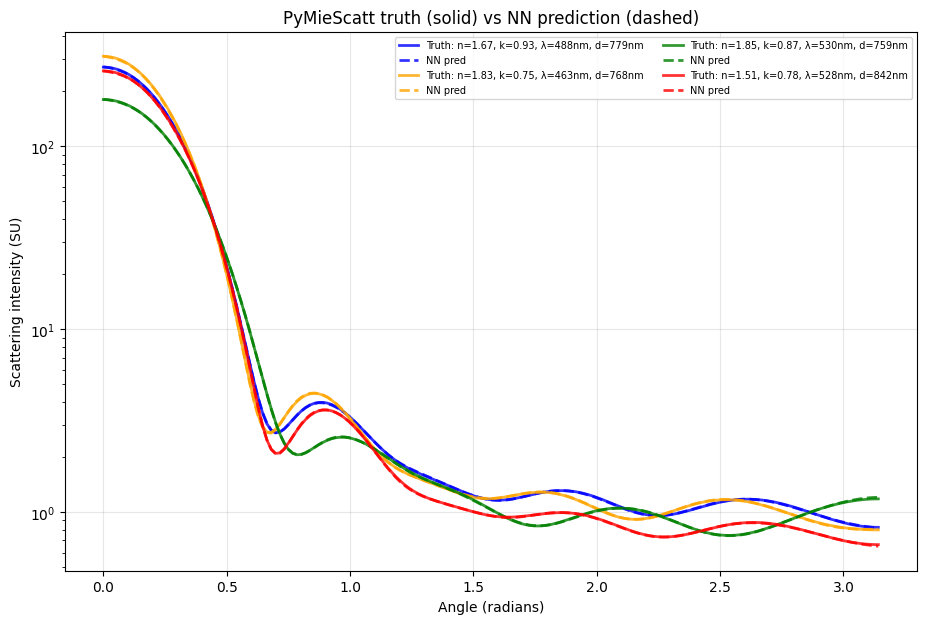

In [10]:
print("Printing X_test")
print(X_test)

# make predictions using the model
with torch.no_grad():
    test_pred = model(X_test)

# number of test particles
n_test_particles = len(X_test) // 181

plt.figure(figsize=(11, 7))
colors = ['blue', 'orange', 'green', 'red']

#pick 4 random particles
particle_indices = np.random.choice(n_test_particles, 4, replace=False)

# plot particles and their angles
for p_idx, color in zip(particle_indices, colors):

    # determing index boundries
    start = p_idx * 181
    end = start + 181
    
    # numpy wanted a 2D array, convert back into 1D for graphing
    true_log_curve = y_test[start:end].numpy().flatten()
    pred_log_curve = test_pred[start:end].numpy().flatten()
    
    true_curve = 10 ** true_log_curve
    pred_curve = 10 ** pred_log_curve
    
    # Un-normalize particle parameters
    n  = X_test[start, 0].item() * (1.86 - 1.5) + 1.5
    k  = X_test[start, 1].item() * (1.00 - 0.68) + 0.68
    wl = X_test[start, 2].item() * 100 + 450
    d  = X_test[start, 3].item() * 200 + 700

    # Un-normalize angles: stored as 0-1, multiply by π for radians
    angles_rad = X_test[start:end, 4].numpy() * np.pi
    angles_deg = np.degrees(angles_rad)   # for display only
    
    label = f"n={n:.2f}, k={k:.2f}, λ={wl:.0f}nm, d={d:.0f}nm"
    plt.plot(angles_rad, true_curve, '-',  color=color, linewidth=2, alpha=0.8, label=f"Truth: {label}")
    plt.plot(angles_rad, pred_curve, '--', color=color, linewidth=2, alpha=0.8, label="NN pred")

plt.xlabel("Angle (radians)")
plt.ylabel("Scattering intensity (SU)")
plt.title("PyMieScatt truth (solid) vs NN prediction (dashed)")
plt.yscale('log')
plt.legend(fontsize=7, ncol=2)
plt.grid(True, alpha=0.3)
plt.show()

Todo: Still have to try out the tan h compression function between layers. Try to 

Neural Network Prediction Time
Total time: 0.0021193027s for prediction
PyMieScatt Time
0.020195484161376953 time to compute 180 degrees of a single particle using pyMieScatt
homogeneous particle (on device: cpu)
 - layers   = 1
 - radii    = tensor([450.])nm
 - materials: ['eps=2.61+i3.800']
 - environment    : eps=1.00

Calculating True curve using PyMieDiff
tensor([431.0678, 429.6666, 425.4856, 418.5988, 409.1209, 397.2124, 383.0719,
        366.9324, 349.0538, 329.7182, 309.2247, 287.8788, 265.9890, 243.8577,
        221.7768, 200.0211, 178.8423, 158.4663, 139.0889, 120.8743, 103.9517,
         88.4170,  74.3317,  61.7250,  50.5948,  40.9119,  32.6219,  25.6494,
         19.9017,  15.2729,  11.6478,   8.9059,   6.9250,   5.5842,   4.7675,
          4.3656,   4.2783,   4.4155,   4.6988,   5.0618,   5.4497,   5.8197,
          6.1400,   6.3887,   6.5530,   6.6280,   6.6148,   6.5197,   6.3527,
          6.1263,   5.8542,   5.5505,   5.2287,   4.9012,   4.5790,   4.2710,
          3.9

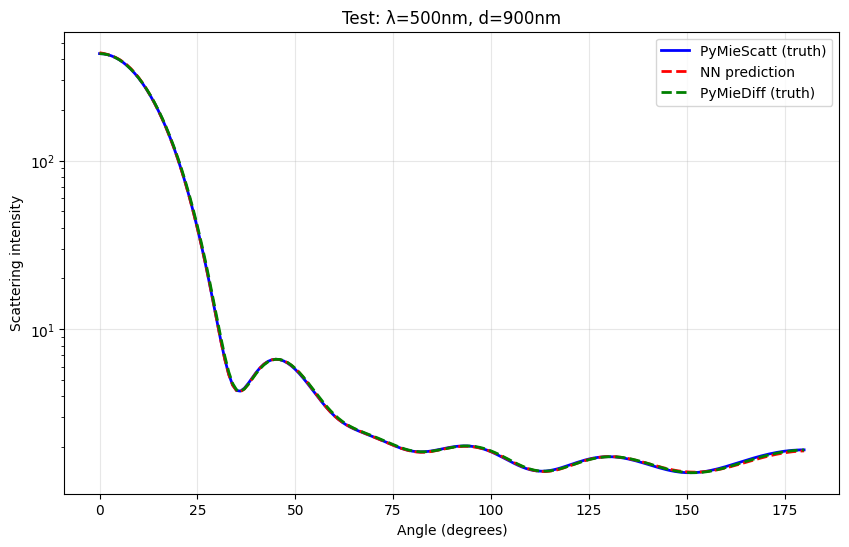

In [11]:

def predict_scattering(n, k, wavelength, diameter, angle=None):
    if angle is None:
        angle = np.arange(0, 181) * np.pi / 180   # 181 angles in radians
    angle = np.atleast_1d(angle)   # make sure it's an array even if user passes one value
    
    n_query = len(angle)
    raw_inputs = np.zeros((n_query, 5))
    raw_inputs[:, 0] = n
    raw_inputs[:, 1] = k
    raw_inputs[:, 2] = wavelength
    raw_inputs[:, 3] = diameter
    raw_inputs[:, 4] = angle
    
    # Normalize each column
    norm = np.zeros_like(raw_inputs)
    norm[:, 0] = (raw_inputs[:, 0] - 1.5) / 0.36
    norm[:, 1] = (raw_inputs[:, 1] - 0.68) / 0.32
    norm[:, 2] = (raw_inputs[:, 2] - 450) / 100
    norm[:, 3] = (raw_inputs[:, 3] - 700) / 200
    norm[:, 4] = raw_inputs[:, 4] / np.pi # model trained onr radians
    
    input_tensor = torch.FloatTensor(norm)
    
    with torch.no_grad():
        log_pred = model(input_tensor)
    
    return 10 ** log_pred.numpy().flatten()


def true_scattering(wavelength, diameter, n, k):
    """Compute the actual PyMieScatt scattering curve."""
    m = complex(n, k) # for any set of parameters

    calculation_start = time.time()

    theta, SL, SR, SU = ps.ScatteringFunction(
        m, wavelength, diameter,
        minAngle=0, maxAngle=180, angularResolution=1
    )

    calculation_end = time.time()
    elapsed = calculation_end - calculation_start
    print(f"{elapsed} time to compute 180 degrees of a single particle using pyMieScatt")

    return SU

def py_Mie_Diff_Scattering(wavelength, diameter, n, k, environment_value = 1.00):
    # - setup the particle
    wl0 = torch.tensor([wavelength]) # converting into what pyMieDiff requires as input
    k0 = 2 * torch.pi / wl0

    p = pmd.Particle(
        r_layers=[diameter/2],
        mat_layers=[n + k*1j],
        mat_env = 1.00
    )

    theta = torch.arange(0, 181) * torch.pi/181
    print(p)

    print("Calculating True curve using PyMieDiff")
    calculation_start = time.time()
    angle_scattering = p.get_angular_scattering(k0= k0, theta = theta)
    print(angle_scattering["i_unpol"])
    calculation_end = time.time()
    print("Time taken to compute the true curve using PyMieDiff:")
    print(calculation_end - calculation_start)
    return angle_scattering['i_unpol']

# Pick any wavelength and diameter to test
test_wavelength = 500  # nm
test_diameter = 900    # nm
test_n = 1.9
test_k = 1.0

# Get both predictions
# get prediction curve

print("Neural Network Prediction Time")
training_start = time.time()

nn_curve = predict_scattering(test_n, test_k, test_wavelength, test_diameter)

elapsed = time.time() - training_start
print(f"Total time: {elapsed:.10f}s for prediction")

print("PyMieScatt Time")

true_curve = true_scattering(test_wavelength, test_diameter, test_n, test_k)

true_curve_with_pyMieDiff = py_Mie_Diff_Scattering(test_wavelength, test_diameter, test_n, test_k)

# Calculate error
error = np.mean((np.log10(nn_curve) - np.log10(true_curve))**2)
print(f"Mean squared error (in log space): {error:.6e}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(true_curve, '-',  color='blue', linewidth=2, label='PyMieScatt (truth)')
plt.plot(nn_curve,   '--', color='red',  linewidth=2, label='NN prediction')
plt.plot(true_curve_with_pyMieDiff, '--', color= 'green', linewidth= 2, label = 'PyMieDiff (truth)')
plt.xlabel("Angle (degrees)")
plt.ylabel("Scattering intensity")
plt.title(f"Test: λ={test_wavelength}nm, d={test_diameter}nm")
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

works well

This section is used to generate some 2d plots. We'll begin by generating the logspaced diameter testing data.

In [12]:
N_D_SPANNING_DATA = 200
m = complex(1.6, 1.0) # match the m value the NN was trained on
fixed_lambda = 500 # I will be varying diameter not wavelength

# Log-spaced diameter sweep — wider than training range
d_span = np.logspace(np.log10(400), np.log10(900), N_D_SPANNING_DATA)

print("Computing Brightness for Each Diamaeter with PyMieScatt")
truth = np.zeros((N_D_SPANNING_DATA, 181)) # create array of 181 arrays which have values of 0

# generate the pyMieScatt curve for each diameter value
for i, d in enumerate(d_span):
    theta, SL, SR, SU = ps.ScatteringFunction(
        m, fixed_lambda, d, minAngle=0, maxAngle=180, angularResolution=1
    )

    # add it in it's spot in the array
    truth[i] = SU
    if i % 50 == 0:
        print(f"  {i}/{N_D_SPANNING_DATA}") 
# print(truth)
# === Predictions from NN ===
print("Computing NN sweep...")
nn_pred = np.zeros((N_D_SPANNING_DATA, 181))

for k, d in enumerate(d_span):
    nn_pred[k] = predict_scattering(
        n=1.6,
        k=1.0,
        wavelength=fixed_lambda,
        diameter=d
    )
# print(nn_pred)

print(f"\nDone!")
print(f"Diameter range: {d_span[0]:.0f} to {d_span[-1]:.0f} nm")
print(f"Training was: 700 to 900 nm")


Computing Brightness for Each Diamaeter with PyMieScatt
  0/200
  50/200
  100/200
  150/200
Computing NN sweep...

Done!
Diameter range: 400 to 900 nm
Training was: 700 to 900 nm


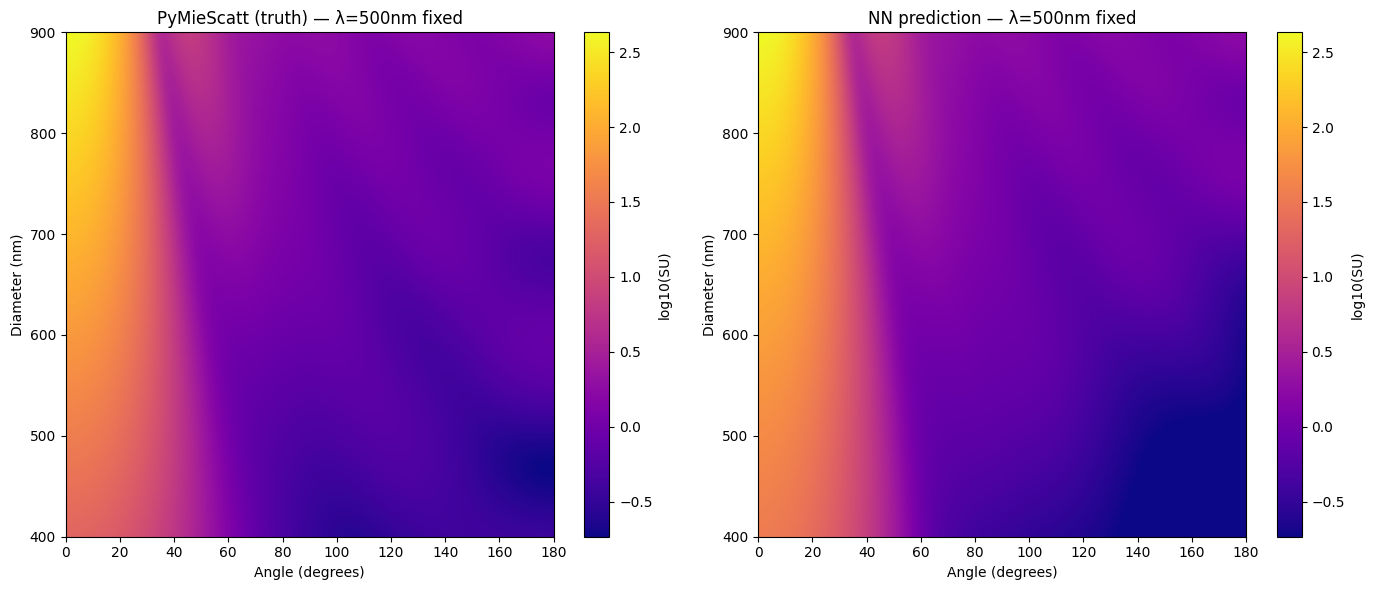

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Use the same color scale across both plots so they're directly comparable
vmin = np.log10(truth).min()
vmax = np.log10(truth).max()

# === PyMieScatt truth ===
im1 = axes[0].imshow(
    np.log10(truth),
    aspect='auto', origin='lower',
    extent=[0, 180, d_span[0], d_span[-1]],
    cmap='plasma', vmin=vmin, vmax=vmax
)
axes[0].set_title(f"PyMieScatt (truth) — λ={fixed_lambda}nm fixed")
axes[0].set_xlabel("Angle (degrees)")
axes[0].set_ylabel("Diameter (nm)")
# Show training range boundaries
plt.colorbar(im1, ax=axes[0], label='log10(SU)')

# === NN prediction ===
im2 = axes[1].imshow(
    np.log10(nn_pred),
    aspect='auto', origin='lower',
    extent=[0, 180, d_span[0], d_span[-1]],
    cmap='plasma', vmin=vmin, vmax=vmax
)
axes[1].set_title(f"NN prediction — λ={fixed_lambda}nm fixed")
axes[1].set_xlabel("Angle (degrees)")
axes[1].set_ylabel("Diameter (nm)")
plt.colorbar(im2, ax=axes[1], label='log10(SU)')

plt.tight_layout()
plt.show()

In [14]:
# Test 1: Predictions should vary with input
pred_1 = predict_scattering(1.7, 0.85, 500, 800, 80)
pred_2 = predict_scattering(1.5, 0.7, 480, 750, 80)

print(f"Pred 1 mean: {pred_1.mean():.4f}")
print(f"Pred 2 mean: {pred_2.mean():.4f}")
print(f"Are they different? {not np.allclose(pred_1, pred_2)}")

Pred 1 mean: 0.0000
Pred 2 mean: 0.0000
Are they different? False


homogeneous particle (on device: cpu)
 - layers   = 1
 - radii    = tensor([400])nm
 - materials: ['eps=2.17+i2.890']
 - environment    : eps=1.00

Printing predictions
tensor([[ 2.4335e+00],
        [ 2.4302e+00],
        [ 2.4257e+00],
        [ 2.4196e+00],
        [ 2.4118e+00],
        [ 2.4019e+00],
        [ 2.3897e+00],
        [ 2.3750e+00],
        [ 2.3577e+00],
        [ 2.3377e+00],
        [ 2.3149e+00],
        [ 2.2895e+00],
        [ 2.2613e+00],
        [ 2.2306e+00],
        [ 2.1972e+00],
        [ 2.1614e+00],
        [ 2.1229e+00],
        [ 2.0818e+00],
        [ 2.0377e+00],
        [ 1.9907e+00],
        [ 1.9403e+00],
        [ 1.8862e+00],
        [ 1.8284e+00],
        [ 1.7664e+00],
        [ 1.7001e+00],
        [ 1.6296e+00],
        [ 1.5546e+00],
        [ 1.4753e+00],
        [ 1.3918e+00],
        [ 1.3038e+00],
        [ 1.2112e+00],
        [ 1.1137e+00],
        [ 1.0113e+00],
        [ 9.0485e-01],
        [ 7.9669e-01],
        [ 6.9116e-01],
   

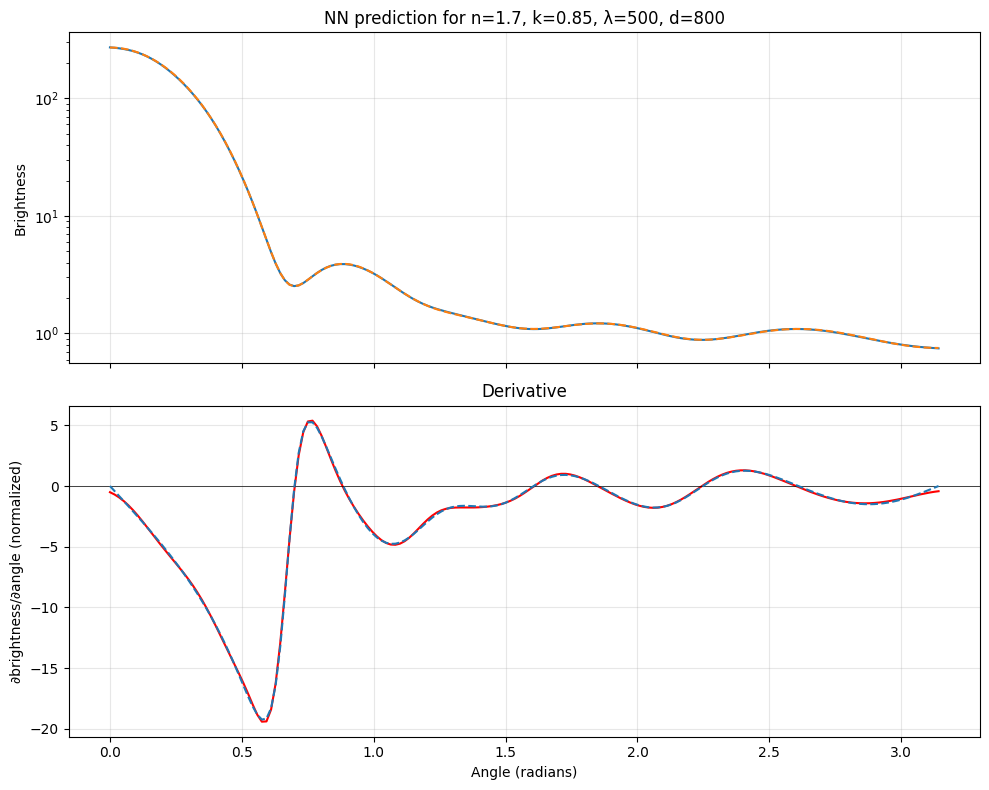

tensor([270.6148, 269.9022, 267.7741, 264.2600, 259.4091, 253.2878, 245.9793,
        237.5822, 228.2077, 217.9788, 207.0256, 195.4853, 183.4980, 171.2047,
        158.7444, 146.2530, 133.8593, 121.6844, 109.8391,  98.4225,  87.5219,
         77.2106,  67.5484,  58.5803,  50.3381,  42.8396,  36.0899,  30.0822,
         24.7984,  20.2114,  16.2855,  12.9782,  10.2419,   8.0249,   6.2732,
          4.9317,   3.9455,   3.2611,   2.8271,   2.5952,   2.5210,   2.5643,
          2.6894,   2.8655,   3.0665,   3.2711,   3.4625,   3.6282,   3.7595,
          3.8510,   3.9004,   3.9080,   3.8759,   3.8079,   3.7088,   3.5841,
          3.4397,   3.2814,   3.1148,   2.9452,   2.7770,   2.6141,   2.4596,
          2.3157,   2.1840,   2.0654,   1.9600,   1.8674,   1.7870,   1.7177,
          1.6580,   1.6066,   1.5619,   1.5226,   1.4873,   1.4548,   1.4243,
          1.3948,   1.3659,   1.3374,   1.3090,   1.2810,   1.2534,   1.2267,
          1.2013,   1.1776,   1.1562,   1.1374,   1.1216,   1.10

In [15]:
# particle to analyze
n = 1.7
k = 0.85
wavelength = 500
diameter = 800

# build input for one specific particle at all angles
angles_rad = np.linspace(0, np.pi, 181)
raw_inputs = np.zeros((181, 5))
raw_inputs[:, 0] = n 
raw_inputs[:, 1] = k 
raw_inputs[:, 2] = wavelength 
raw_inputs[:, 3] = diameter 
raw_inputs[:, 4] = angles_rad

input_min = [1.5, 0.68, 450, 700, 0]
input_range = [0.36, 0.32, 100, 200, np.pi]
# Normalize (same as training)
norm = (raw_inputs - input_min) / input_range
X = torch.FloatTensor(norm)
X.requires_grad_(True)   # turn on gradient tracking


# - config for PyMieDiff using k0
wl0 = torch.tensor([500])
k0 = 2 * torch.pi / wl0

# - setup the particle, pyMieDiff
p = pmd.Particle(
    r_layers=[400],
    mat_layers=[n + k*1j],
    mat_env = 1.00
)

# using pyMieDiff to calculate scattering
theta_norm = torch.linspace(0, 1, 181, requires_grad=True) #neural network works with normalized radian values, so must use the same here when differentiating
theta_rad = theta_norm * torch.pi



print(p)

angle_scattering = p.get_angular_scattering(k0= k0, theta = theta_rad)

# calculating the dBrightness/dAngle
angle_scattering_grad = torch.autograd.grad(torch.log10(angle_scattering['i_unpol']).sum(), theta_norm, create_graph=False)[0]
d_pyMieDiff_d_angle = angle_scattering_grad.detach().numpy()

# Forward pass, pytorch builds a graph of the operations it performs when predicting
pred = model(X)   # shape (181, 1)

# Compute derivatives of all predictions w.r.t. all inputs
nn_grad = torch.autograd.grad(pred.sum(), X, create_graph=False)[0]
# Shape (181, 5), 5 derivatives per prediction each w.r.t. one of the five parameters

# Extract just the angle derivative
d_pred_d_angle = nn_grad[:, 4].detach().numpy()

# The prediction itself (un-log for real brightness), have to detach the gradient tracking since numpy doesn't understand gradient tracking. Flatten into a 1d array
pred_curve = (10 ** pred.detach().numpy()).flatten()

print("Printing predictions")

print(pred)
# Plot both
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(angles_rad, pred_curve)
axes[0].set_yscale('log')
axes[0].set_ylabel('Brightness')
axes[0].set_title(f'NN prediction for n={n}, k={k}, λ={wavelength}, d={diameter}')
axes[0].grid(True, alpha=0.3)

axes[1].plot(angles_rad, d_pred_d_angle, color='red')
axes[1].set_xlabel('Angle (radians)')
axes[1].set_ylabel('∂brightness/∂angle (normalized)')
axes[1].set_title('Derivative')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='black', linewidth=0.5)


axes[0].plot(angles_rad, angle_scattering['i_unpol'].detach().numpy(), "--")
axes[1].plot(theta_rad.detach().numpy(), d_pyMieDiff_d_angle, "--")


plt.tight_layout()
plt.show()

print(angle_scattering['i_unpol'])
print(10**pred)
print(X)
print(theta)

Running benchmark with 10 repetitions per method...

Run 1/10: NN=0.44ms  PyMieScatt=20.05ms  pyMieDiff=9.08ms
Run 2/10: NN=0.33ms  PyMieScatt=19.45ms  pyMieDiff=7.72ms
Run 3/10: NN=0.33ms  PyMieScatt=21.92ms  pyMieDiff=8.05ms
Run 4/10: NN=0.34ms  PyMieScatt=21.98ms  pyMieDiff=9.36ms
Run 5/10: NN=0.34ms  PyMieScatt=20.75ms  pyMieDiff=7.91ms
Run 6/10: NN=0.29ms  PyMieScatt=18.53ms  pyMieDiff=9.11ms
Run 7/10: NN=0.35ms  PyMieScatt=18.70ms  pyMieDiff=7.97ms
Run 8/10: NN=0.58ms  PyMieScatt=21.25ms  pyMieDiff=8.66ms
Run 9/10: NN=0.37ms  PyMieScatt=18.14ms  pyMieDiff=7.01ms
Run 10/10: NN=0.32ms  PyMieScatt=21.62ms  pyMieDiff=9.22ms

--- Average times ---
NN:         0.37 ms (±0.08 ms)
PyMieScatt: 20.24 ms (±1.39 ms)
pyMieDiff:  8.41 ms (±0.75 ms)


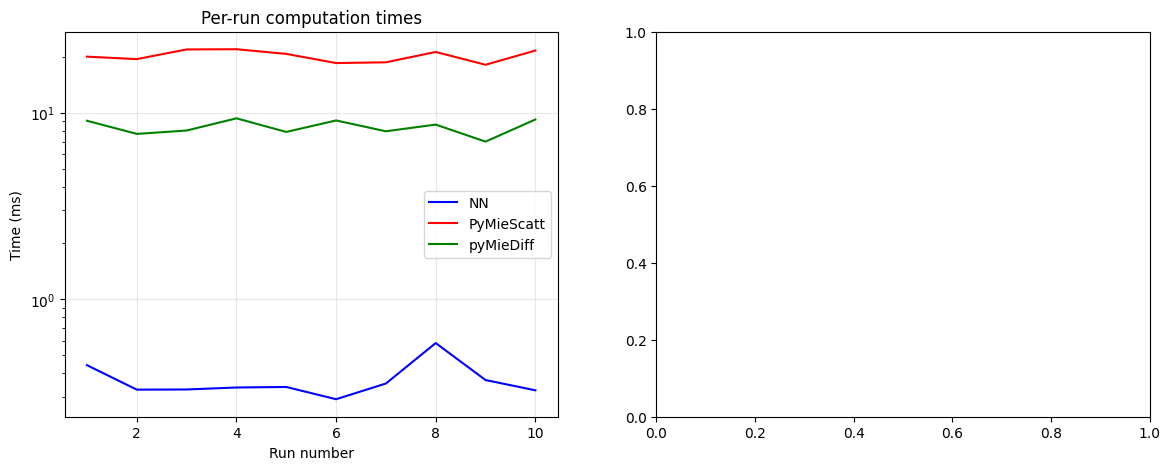

In [16]:
import time

# Test parameters
n = 1.7
k = 0.85
wavelength = 500
diameter = 800

# Number of times to repeat each test (for averaging)
N_RUNS = 10

# Lists to store times
nn_times = []
pymiescatt_times = []
pymiediff_times = []

print(f"Running benchmark with {N_RUNS} repetitions per method...\n")

for run in range(N_RUNS):
    # --- Time NN prediction ---
    start = time.time()
    _ = predict_scattering(n, k, wavelength, diameter)
    nn_times.append(time.time() - start)
    
    # --- Time PyMieScatt ---
    start = time.time()
    m = complex(n, k)
    theta, SL, SR, SU = ps.ScatteringFunction(
        m, wavelength, diameter,
        minAngle=0, maxAngle=180, angularResolution=1
    )
    pymiescatt_times.append(time.time() - start)
    
    # --- Time pyMieDiff ---
    start = time.time()
    wl0 = torch.tensor([float(wavelength)])
    k0 = 2 * torch.pi / wl0
    p = pmd.Particle(
        r_layers=[diameter/2],
        mat_layers=[n + k*1j],
        mat_env=1.00
    )
    theta_t = torch.arange(0, 181) * torch.pi/181
    angle_scattering = p.get_angular_scattering(k0=k0, theta=theta_t)
    pymiediff_times.append(time.time() - start)
    
    print(f"Run {run+1}/{N_RUNS}: NN={nn_times[-1]*1000:.2f}ms  PyMieScatt={pymiescatt_times[-1]*1000:.2f}ms  pyMieDiff={pymiediff_times[-1]*1000:.2f}ms")

# Summary stats
print(f"\n--- Average times ---")
print(f"NN:         {np.mean(nn_times)*1000:.2f} ms (±{np.std(nn_times)*1000:.2f} ms)")
print(f"PyMieScatt: {np.mean(pymiescatt_times)*1000:.2f} ms (±{np.std(pymiescatt_times)*1000:.2f} ms)")
print(f"pyMieDiff:  {np.mean(pymiediff_times)*1000:.2f} ms (±{np.std(pymiediff_times)*1000:.2f} ms)")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: time series of each run
axes[0].plot(range(1, N_RUNS+1), [t*1000 for t in nn_times], label='NN', color='blue')
axes[0].plot(range(1, N_RUNS+1), [t*1000 for t in pymiescatt_times], label='PyMieScatt', color='red')
axes[0].plot(range(1, N_RUNS+1), [t*1000 for t in pymiediff_times], label='pyMieDiff', color='green')
axes[0].set_xlabel('Run number')
axes[0].set_ylabel('Time (ms)')
axes[0].set_title('Per-run computation times')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

plt.show()

In [17]:
import sys
print(sys.executable)

c:\Users\james\AppData\Local\Python\pythoncore-3.14-64\python.exe
